# Data gathering and preprocessing

## Imports

In [2]:
import kagglehub
import pandas as pd
import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# kagglehub.dataset_download("jessemostipak/hotel-booking-demand", output_dir="./Dataset")
ds = pd.read_csv("./Dataset/hotel_bookings.csv").sample(30000, random_state=268555)
# ds = pd.read_csv("./Dataset/hotel_bookings.csv")

c:\Users\kkacp\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data checks

### Understanding given data

In [3]:
ds.info()

def printMissingDataSummary(ds):
    missingCount = ds.isna().sum()
    missingPercentage = (missingCount / len(ds) * 100).round(2)

    missingSummary = pd.DataFrame({
        "missingCount": missingCount,
        "missingPercentage": missingPercentage
    })

    print("\nMissing data summary:")
    print(missingSummary)

printMissingDataSummary(ds)

<class 'pandas.core.frame.DataFrame'>
Index: 30000 entries, 25367 to 3740
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           30000 non-null  object 
 1   is_canceled                     30000 non-null  int64  
 2   lead_time                       30000 non-null  int64  
 3   arrival_date_year               30000 non-null  int64  
 4   arrival_date_month              30000 non-null  object 
 5   arrival_date_week_number        30000 non-null  int64  
 6   arrival_date_day_of_month       30000 non-null  int64  
 7   stays_in_weekend_nights         30000 non-null  int64  
 8   stays_in_week_nights            30000 non-null  int64  
 9   adults                          30000 non-null  int64  
 10  children                        29999 non-null  float64
 11  babies                          30000 non-null  int64  
 12  meal                            30

### Dealing with missing data #1

In [4]:
ds.drop(columns=["company"], inplace=True)
ds.drop(columns=["is_canceled"], inplace=True)
ds = ds.loc[ds["country"].notna()].copy()
ds = ds.loc[ds["children"].notna()].copy()

In [5]:
ds.describe(include="object")

ds["reservation_status_date"] = pd.to_datetime(ds["reservation_status_date"], errors="coerce")

month_map = {
    "January": 1,
    "February": 2,
    "March": 3,
    "April": 4,
    "May": 5,
    "June": 6,
    "July": 7,
    "August": 8,
    "September": 9,
    "October": 10,
    "November": 11,
    "December": 12,
}
ds["arrival_date_month"] = ds["arrival_date_month"].map(month_map)

ds.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29861 entries, 25367 to 3740
Data columns (total 30 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   hotel                           29861 non-null  object        
 1   lead_time                       29861 non-null  int64         
 2   arrival_date_year               29861 non-null  int64         
 3   arrival_date_month              29861 non-null  int64         
 4   arrival_date_week_number        29861 non-null  int64         
 5   arrival_date_day_of_month       29861 non-null  int64         
 6   stays_in_weekend_nights         29861 non-null  int64         
 7   stays_in_week_nights            29861 non-null  int64         
 8   adults                          29861 non-null  int64         
 9   children                        29861 non-null  float64       
 10  babies                          29861 non-null  int64         
 11  meal

### Dealing with time in data

In [6]:
ds['arrival_date'] = pd.to_datetime(
    ds['arrival_date_year'].astype(str) + '-' +
    ds['arrival_date_month'].astype(str) + '-' +
    ds['arrival_date_day_of_month'].astype(str),
    errors='coerce'
)

if 'reservation_status' in ds.columns:
    checkOutDf = ds.loc[ds['reservation_status'] == 'Check-Out'].copy()

    checkOutDf['days_diff'] = (
        checkOutDf['reservation_status_date'] - checkOutDf['arrival_date']
    ).dt.days
    checkOutDf['expected_nights'] = (
        checkOutDf['stays_in_week_nights'] + checkOutDf['stays_in_weekend_nights']
    )
    checkOutDf['is_valid_stay'] = checkOutDf['days_diff'] == checkOutDf['expected_nights']

    invalidRows = checkOutDf.loc[~checkOutDf['is_valid_stay']].copy()

    if not invalidRows.empty:
        ds = ds.drop(index=invalidRows.index).copy()
        print(f"Dropped invalid rows: {len(invalidRows)}")

ds = ds[ds['arrival_date'].notna()].copy()

ds.drop(columns=['arrival_date_year', 'arrival_date_month', 'arrival_date_day_of_month'], inplace=True)

Dropped invalid rows: 10


### Dealing with orphans

In [7]:
ds = ds[ds['adults'] != 0]

### Dealing with missing data #2

In [8]:
trainDf = ds[ds["agent"].notna()].copy()
predictDf = ds[ds["agent"].isna()].copy()

y = trainDf["agent"]
X = trainDf.drop(columns=["agent"])
predX = predictDf.drop(columns=["agent"])

catCols = X.select_dtypes(include=["object", "category"]).columns.tolist()
numCols = X.select_dtypes(include=["number"]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", sklearn.preprocessing.OneHotEncoder(handle_unknown="ignore"), catCols),
        ("num", "passthrough", numCols),
    ]
)

model = sklearn.pipeline.Pipeline([
    ("pre", preprocessor),
    ("clf", RandomForestClassifier(n_estimators=100, random_state=268555))
])

trainX, valX, trainY, valY = sklearn.model_selection.train_test_split(X, y, test_size=0.2, random_state=268555)

model.fit(trainX, trainY)
print("val score:", model.score(valX, valY))

predictedAgents = model.predict(predX)

ds.loc[ds["agent"].isna(), "agent"] = predictedAgents

val score: 0.8307453416149069


In [9]:
printMissingDataSummary(ds)


Missing data summary:
                                missingCount  missingPercentage
hotel                                      0                0.0
lead_time                                  0                0.0
arrival_date_week_number                   0                0.0
stays_in_weekend_nights                    0                0.0
stays_in_week_nights                       0                0.0
adults                                     0                0.0
children                                   0                0.0
babies                                     0                0.0
meal                                       0                0.0
country                                    0                0.0
market_segment                             0                0.0
distribution_channel                       0                0.0
is_repeated_guest                          0                0.0
previous_cancellations                     0                0.0
previous_bookings

In [10]:
def printColumnValueCounts(ds):
    print(ds.nunique(dropna=False))

    rows = []
    for col in ds.columns:
        counts = ds[col].value_counts(dropna=False).sort_values(ascending=False)
        for val, cnt in counts.items():
            rows.append({
                "column": col,
                "value": str(val),
                "count": cnt
            })

    result = pd.DataFrame(rows)
    result.to_csv("./Dataset/column_value_counts.csv", index=False, encoding="utf-8-sig")
    print("Wrote", len(result), "rows to column_value_counts.csv")

printColumnValueCounts(ds)

hotel                                2
lead_time                          465
arrival_date_week_number            53
stays_in_weekend_nights             11
stays_in_week_nights                25
adults                               9
children                             5
babies                               3
meal                                 5
country                            140
market_segment                       7
distribution_channel                 4
is_repeated_guest                    2
previous_cancellations              14
previous_bookings_not_canceled      42
reserved_room_type                   9
assigned_room_type                  10
booking_changes                     12
deposit_type                         3
agent                              277
days_in_waiting_list               101
customer_type                        4
adr                               4304
required_car_parking_spaces          4
total_of_special_requests            6
reservation_status       

### Correlation matrix presentation

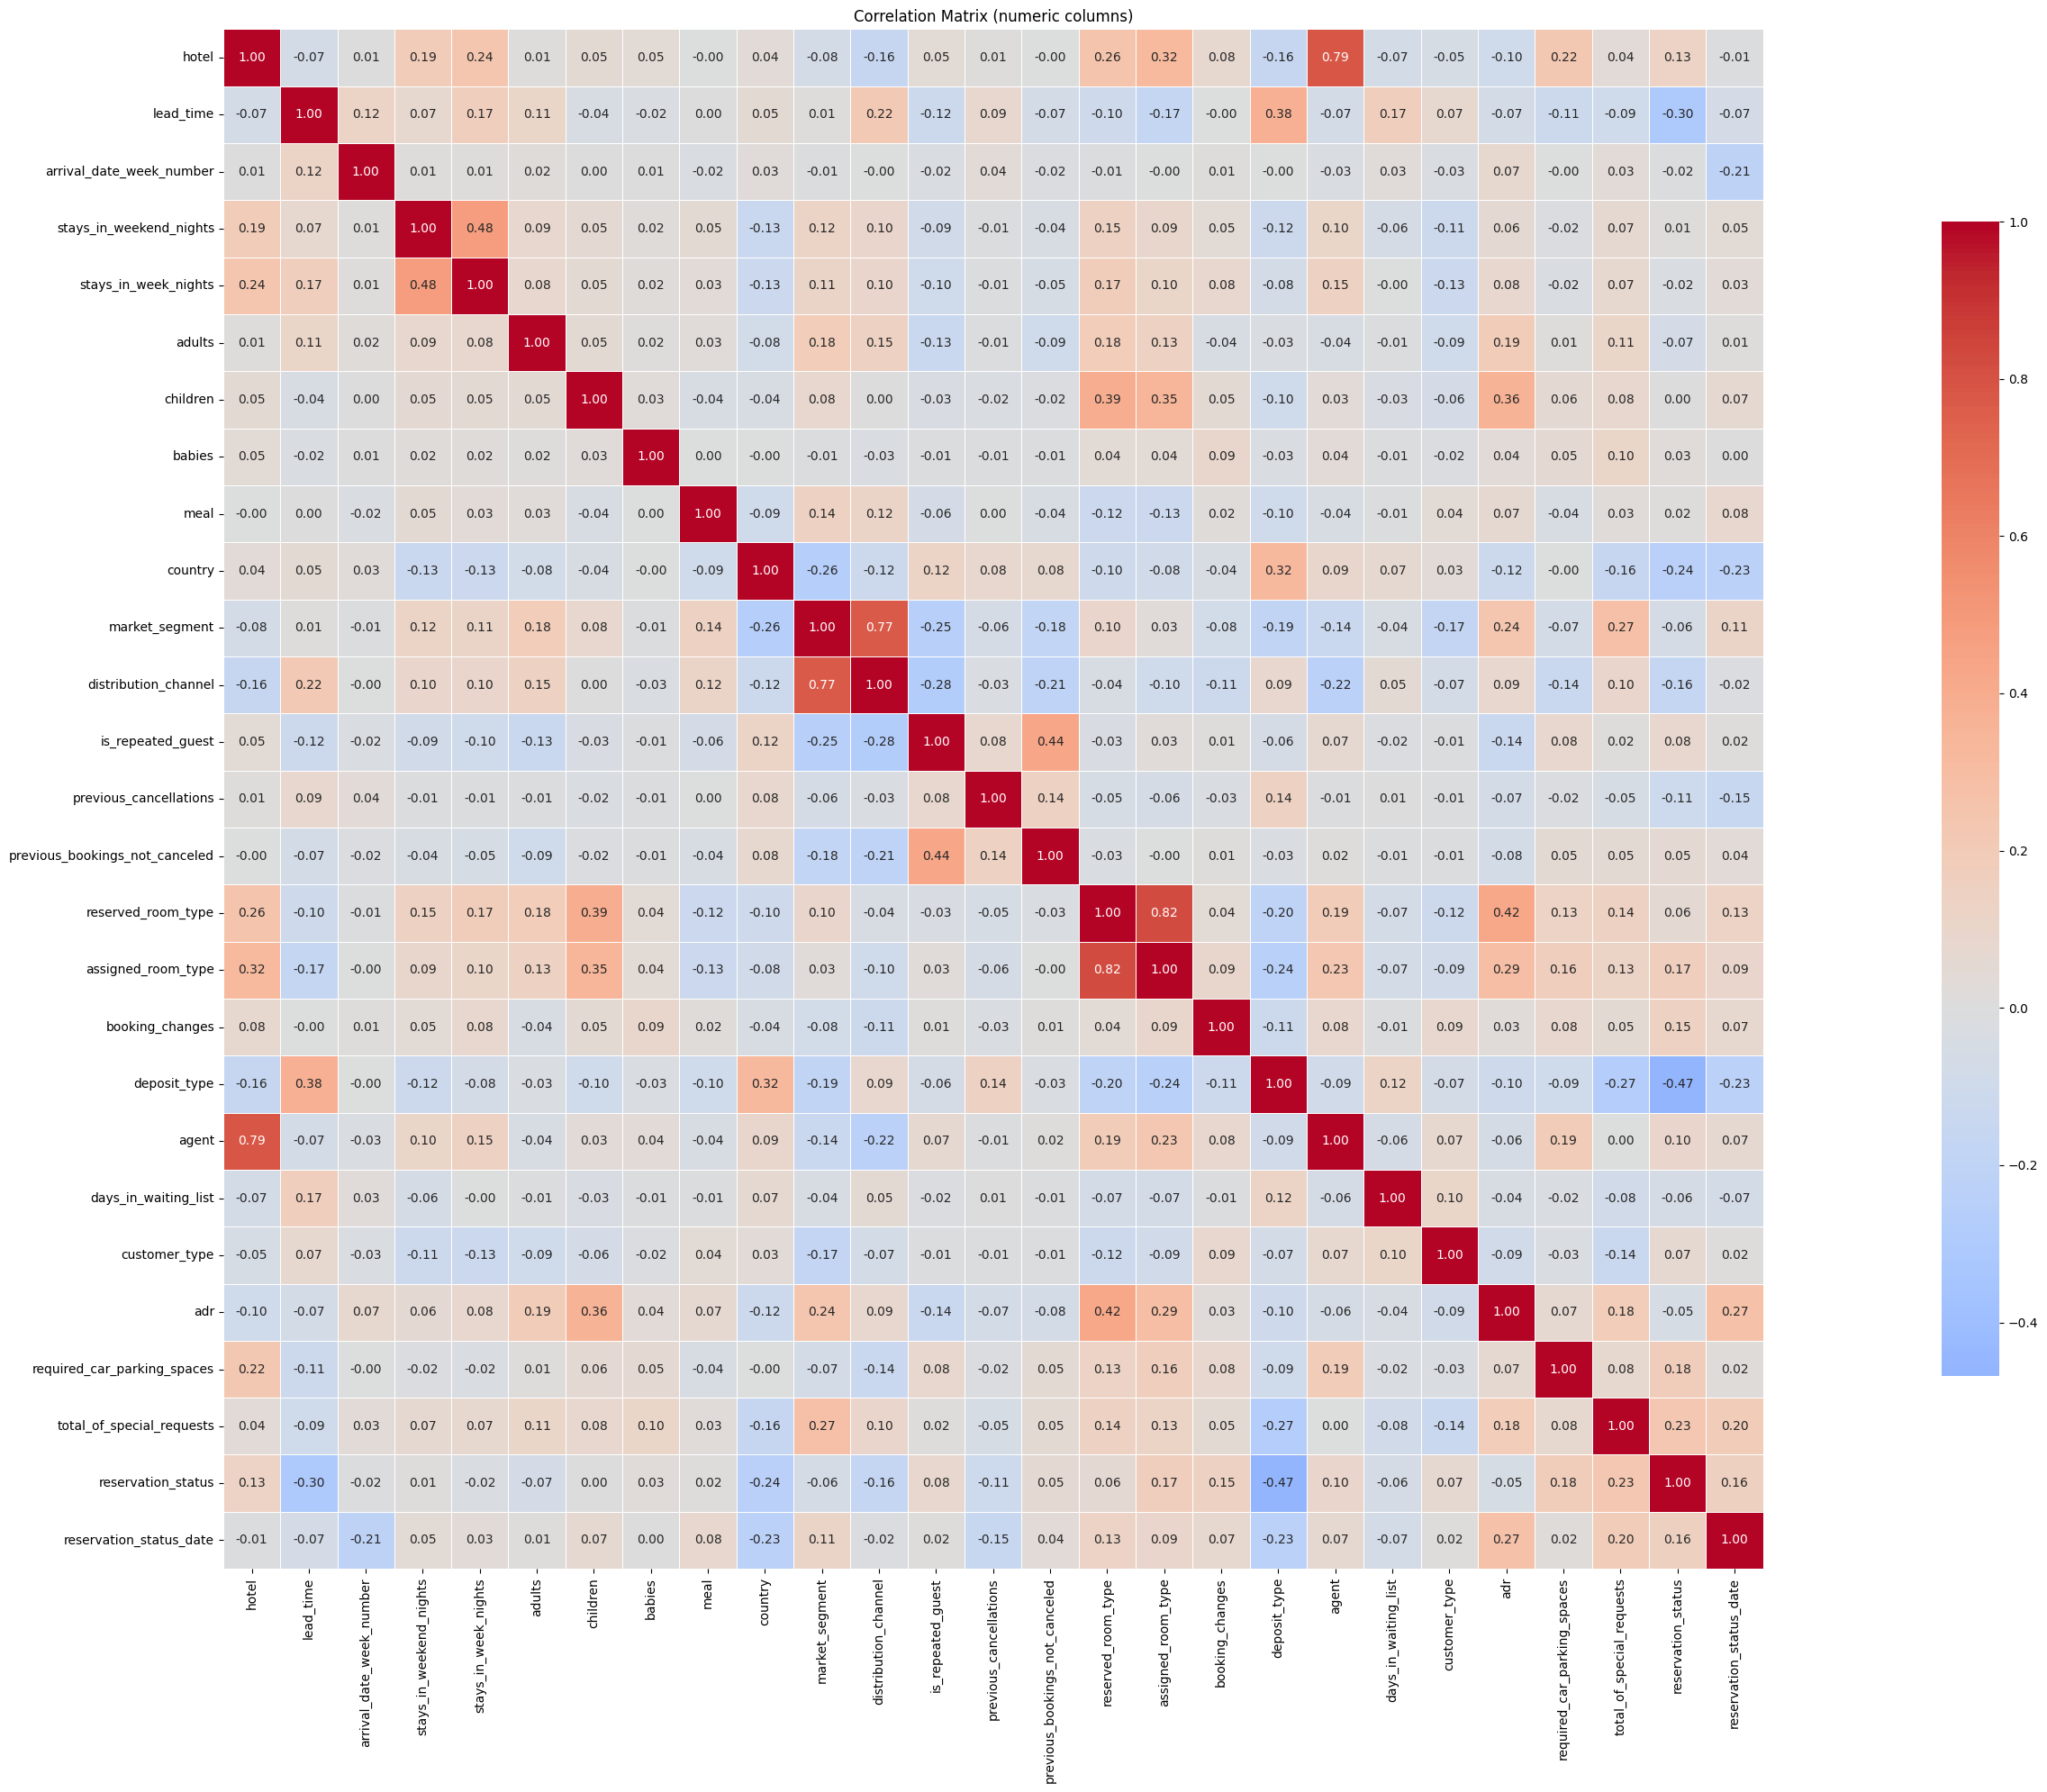

In [11]:
for col in ds.select_dtypes(include=['object']).columns:
        if col != 'reservation_status_date' and col != 'country' and col != 'hotel':
            ds[col] = ds[col].astype('category').cat.codes

def printComputationMatrix(ds):
    corrDf = ds.copy()

    if "country" in corrDf.columns:
        corrDf["country"] = corrDf["country"].astype("category").cat.codes.astype(int)

    if "hotel" in corrDf.columns:
        corrDf["hotel"] = corrDf["hotel"].astype("category").cat.codes.astype(int)

    if "reservation_status_date" in corrDf.columns:
        corrDf["reservation_status_date"] = corrDf["reservation_status_date"].astype("category").cat.codes.astype(int)

    corr = corrDf.corr(numeric_only=True)

    plt.figure(figsize=(40, 20))
    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        square=True,
        linewidths=0.5,
        cbar_kws={"shrink": 0.75}
    )
    plt.title("Correlation Matrix (numeric columns)")
    plt.tight_layout()
    plt.show()

printComputationMatrix(ds)

### Additional visualizations (red-green style)

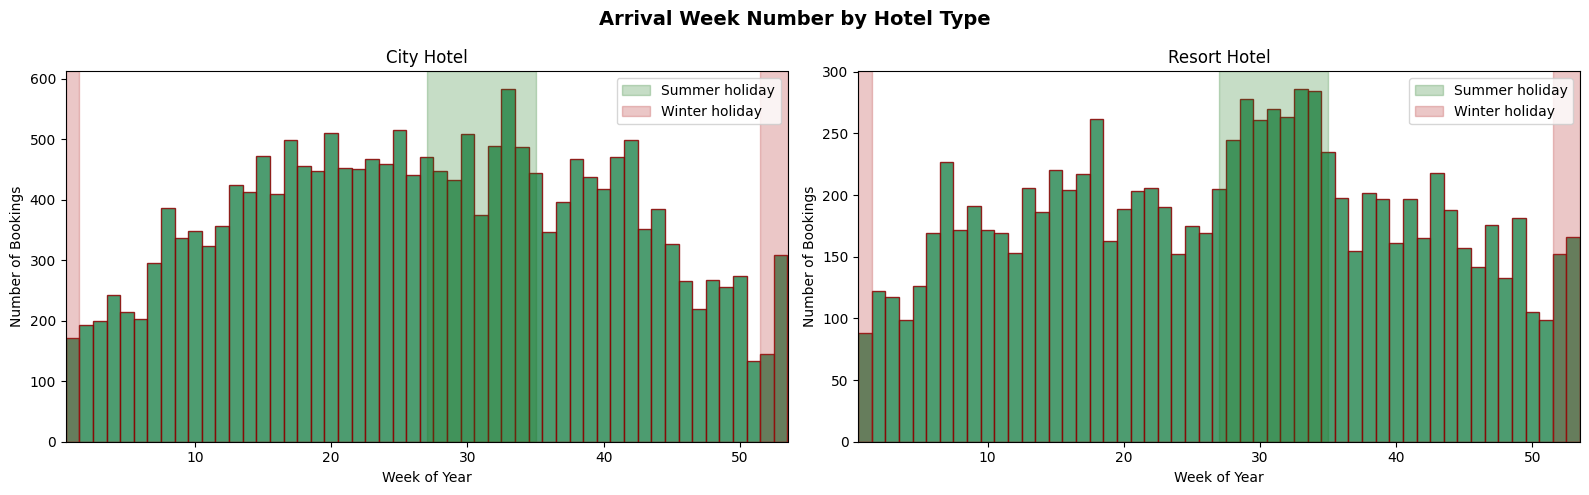

In [12]:
plotDf = ds.copy()

hotelValues = sorted(plotDf["hotel"].dropna().unique())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Arrival Week Number by Hotel Type", fontsize=14, fontweight="bold")

for idx, hotelName in enumerate(hotelValues):
    hotelDf = plotDf.loc[plotDf["hotel"] == hotelName].copy()
    weeks = hotelDf["arrival_date_week_number"].dropna().astype(int)
    bins = np.arange(1, 55) - 0.5
    ax = axes[idx]

    ax.hist(weeks, bins=bins, color="#2e8b57", edgecolor="#8b0000", alpha=0.85)

    ax.axvspan(27, 35, color="#1f7a1f", alpha=0.25, label="Summer holiday")

    ax.axvspan(51.5, 53.5, color="#b22222", alpha=0.25, label="Winter holiday")
    ax.axvspan(0.5, 1.5, color="#b22222", alpha=0.25)

    ax.set_title(f"{hotelName}")
    ax.set_xlabel("Week of Year")
    ax.set_ylabel("Number of Bookings")
    ax.set_xlim(0.5, 53.5)
    ax.legend()

plt.tight_layout()
plt.show()

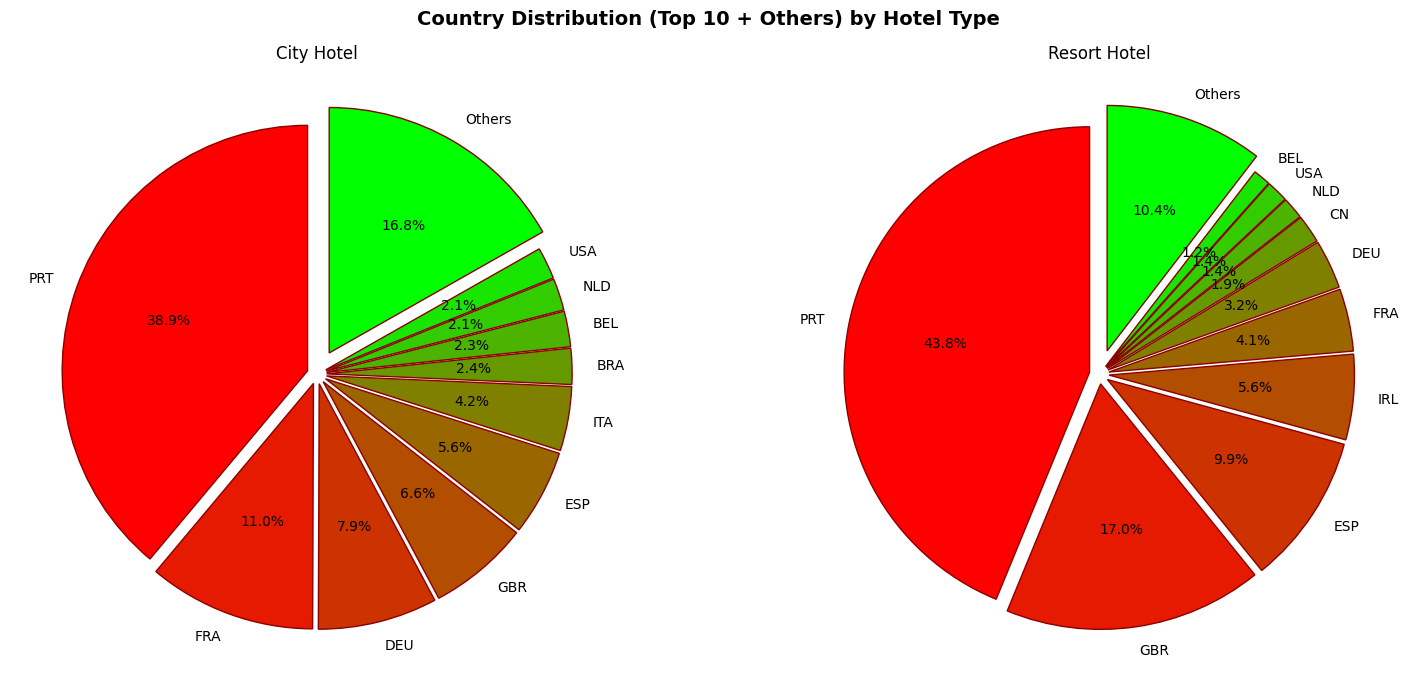

In [13]:
if "plotDf" not in globals():
    plotDf = ds.copy()

hotelValues = sorted(plotDf["hotel"].dropna().unique())

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Country Distribution (Top 10 + Others) by Hotel Type", fontsize=14, fontweight="bold")

for idx, hotelName in enumerate(hotelValues):
    hotelDf = plotDf.loc[plotDf["hotel"] == hotelName].copy()
    countryCounts = hotelDf["country"].value_counts(dropna=False)

    if countryCounts.empty:
        continue

    topN = 10
    pieSeries = countryCounts.head(topN).copy()
    othersCount = countryCounts.iloc[topN:].sum()
    if othersCount > 0:
        pieSeries.loc["Others"] = othersCount

    nSlices = len(pieSeries)
    colorScale = [(1 - t, t, 0) for t in np.linspace(0, 1, nSlices)]

    # Split all slices a bit; split Others more to make it stand out.
    explode = [0.04] * nSlices
    if "Others" in pieSeries.index:
        explode[list(pieSeries.index).index("Others")] = 0.1

    ax = axes[idx]
    ax.pie(
        pieSeries.values,
        labels=pieSeries.index.astype(str),
        autopct="%1.1f%%",
        startangle=90,
        colors=colorScale,
        explode=explode,
        wedgeprops={"edgecolor": "#8b0000", "linewidth": 1.0}
    )
    ax.set_title(f"{hotelName}")

plt.tight_layout()
plt.show()

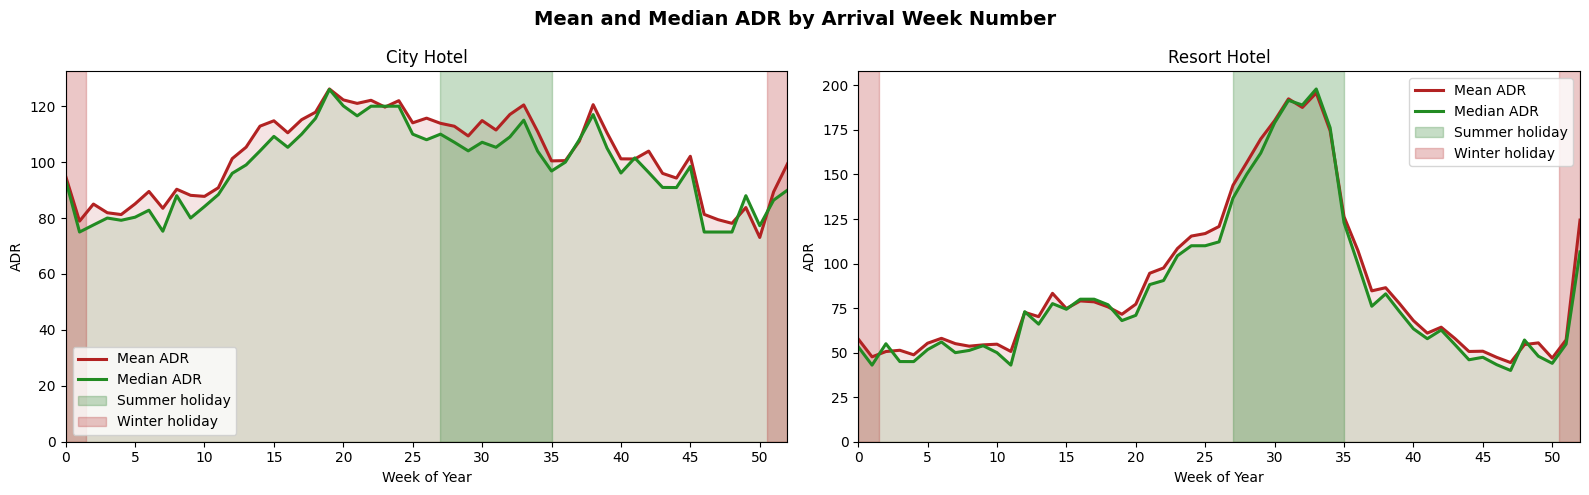

In [16]:
if "plotDf" not in globals():
    plotDf = ds.copy()

hotelValues = sorted(plotDf["hotel"].dropna().unique())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Mean and Median ADR by Arrival Week Number", fontsize=14, fontweight="bold")

for idx, hotelName in enumerate(hotelValues):
    hotelDf = plotDf.loc[plotDf["hotel"] == hotelName].copy()
    adrByWeek = (
        hotelDf[["arrival_date_week_number", "adr"]]
        .dropna()
        .groupby("arrival_date_week_number")["adr"]
        .agg(adr_mean="mean", adr_median="median")
        .sort_index()
    )

    if adrByWeek.empty:
        continue

    xWeeks = adrByWeek.index - 1
    ax = axes[idx]

    ax.plot(xWeeks, adrByWeek["adr_mean"], color="#b22222", linewidth=2.2, label="Mean ADR")
    ax.plot(xWeeks, adrByWeek["adr_median"], color="#228b22", linewidth=2.2, label="Median ADR")
    ax.fill_between(xWeeks, adrByWeek["adr_mean"], color="#b22222", alpha=0.12)
    ax.fill_between(xWeeks, adrByWeek["adr_median"], color="#228b22", alpha=0.12)

    ax.axvspan(27, 35, color="#1f7a1f", alpha=0.25, label="Summer holiday")

    ax.axvspan(50.5, 52, color="#b22222", alpha=0.25, label="Winter holiday")
    ax.axvspan(0, 1.5, color="#b22222", alpha=0.25)

    ax.set_title(f"{hotelName}")
    ax.set_xlabel("Week of Year")
    ax.set_ylabel("ADR")
    ax.set_xlim(0, xWeeks.max())
    ax.set_xticks(np.arange(0, 54, 5))
    ax.set_ylim(bottom=0)
    ax.legend()

plt.tight_layout()
plt.show()

### Relationship: is_repeated_guest vs reservation_status

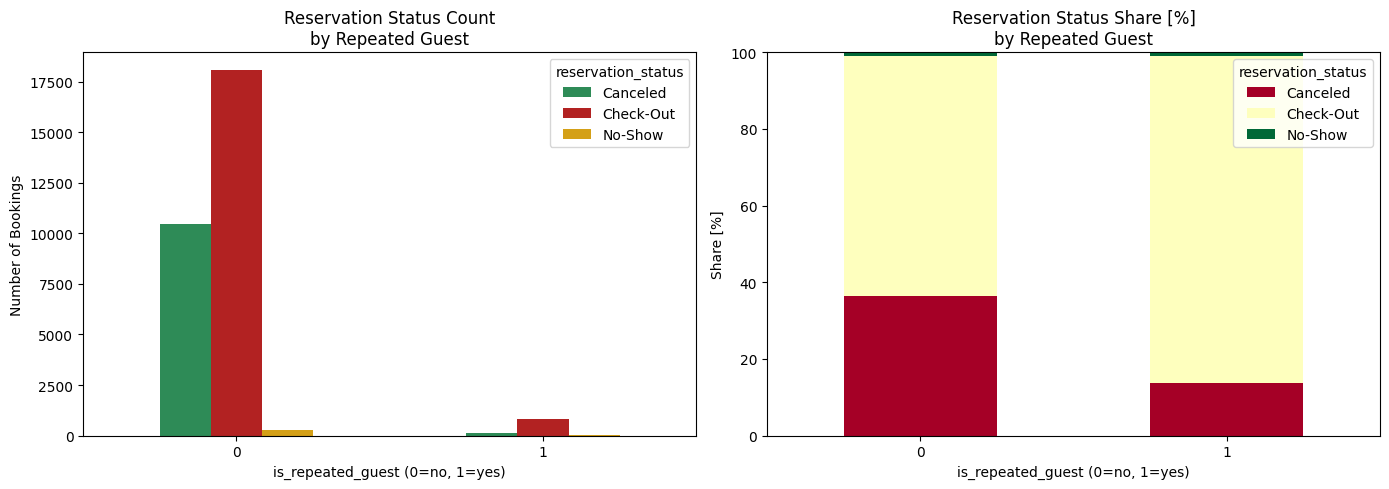

In [ ]:
if "ds" not in globals():
    if pd.io.common.file_exists("./Dataset/hotel_bookings.csv"):
        ds = pd.read_csv("./Dataset/hotel_bookings.csv")
    else:
        ds = pd.read_csv("./Data/hotel_bookings.csv")

plotCols = ["is_repeated_guest", "reservation_status"]
plotData = ds[plotCols].dropna().copy()

if pd.api.types.is_numeric_dtype(plotData["reservation_status"]):
    statusLabelMap = {0: "Canceled", 1: "Check-Out", 2: "No-Show"}
    uniqueStatusValues = set(plotData["reservation_status"].astype(int).unique())
    if uniqueStatusValues.issubset(statusLabelMap.keys()):
        plotData["reservation_status"] = (
            plotData["reservation_status"].astype(int).map(statusLabelMap)
        )

countTable = pd.crosstab(plotData["is_repeated_guest"], plotData["reservation_status"])
shareTable = pd.crosstab(
    plotData["is_repeated_guest"],
    plotData["reservation_status"],
    normalize="index"
).mul(100)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

countTable.plot(kind="bar", ax=axes[0], color=["#2e8b57", "#b22222", "#d4a017"][:countTable.shape[1]])
axes[0].set_title("Reservation Status Count\nby Repeated Guest")
axes[0].set_xlabel("is_repeated_guest (0=no, 1=yes)")
axes[0].set_ylabel("Number of Bookings")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(title="reservation_status")

shareTable.plot(kind="bar", stacked=True, ax=axes[1], colormap="RdYlGn")
axes[1].set_title("Reservation Status Share [%]\nby Repeated Guest")
axes[1].set_xlabel("is_repeated_guest (0=no, 1=yes)")
axes[1].set_ylabel("Share [%]")
axes[1].set_ylim(0, 100)
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="reservation_status", loc="upper right")

plt.tight_layout()
plt.show()